# Task 6 - Manual Region Growing
No prebuilt segmentation function is used.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

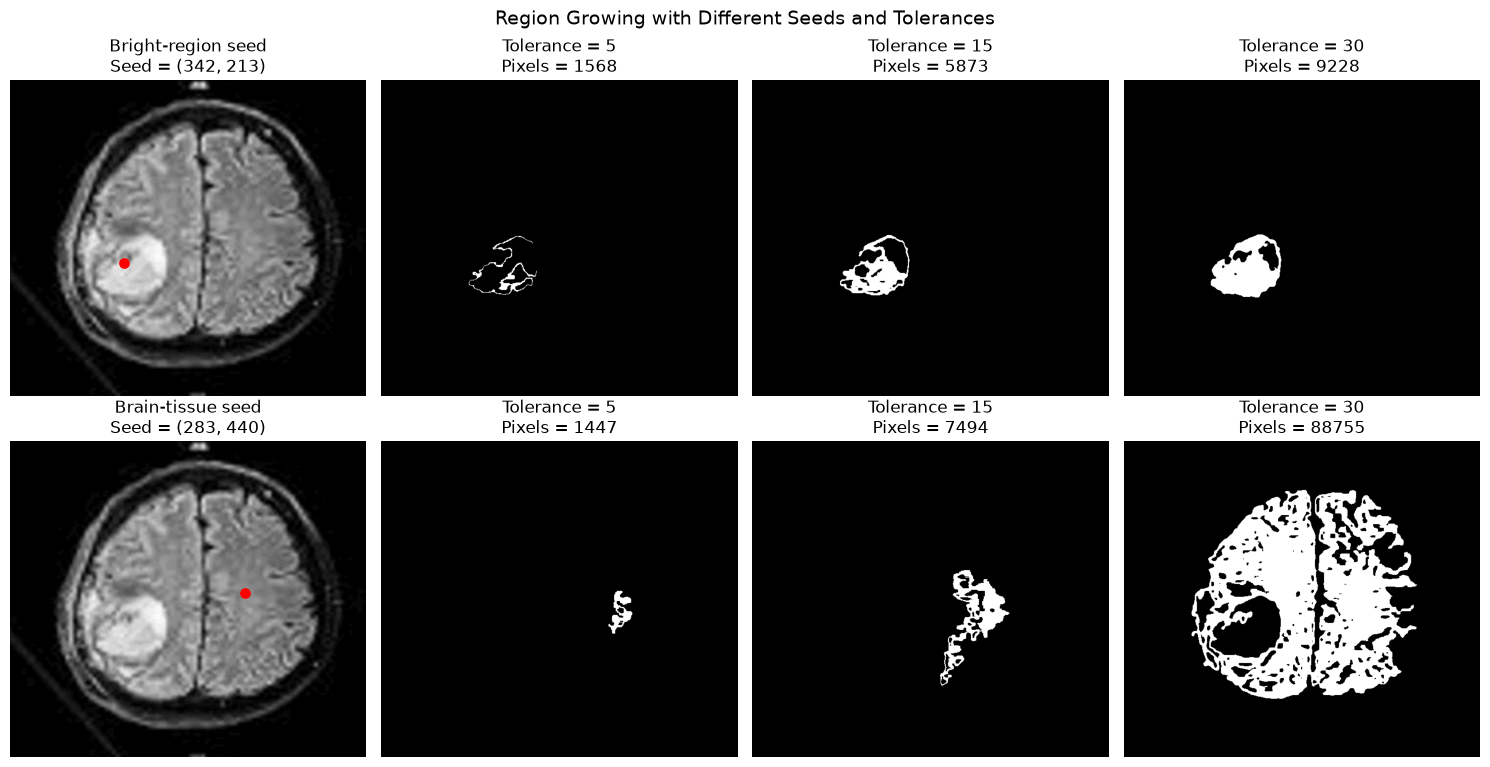

Bright-region seed: (342, 213)
Brain-tissue seed: (283, 440)
Tolerances tested: [5, 15, 30]


In [6]:
gray_full = cv2.imread(
    "mri.png",
    cv2.IMREAD_GRAYSCALE
)

if gray_full is None:
    raise FileNotFoundError(
        "Place the brain MRI as mri.png in the notebook folder."
    )


# ============================================================
# CROP THE ACTUAL MRI REGION
# Removes article title, border and caption from this input image
# ============================================================

# Detect the large dark MRI region
_, dark_mask = cv2.threshold(
    gray_full,
    80,
    255,
    cv2.THRESH_BINARY_INV
)

contours, _ = cv2.findContours(
    dark_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Find sufficiently large dark regions
H, W = gray_full.shape

candidates = []

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    if w > 0.4 * W and h > 0.4 * H:
        candidates.append((x, y, w, h))

# If an appropriate MRI region was detected, crop it
if candidates:
    x, y, w, h = max(
        candidates,
        key=lambda r: r[2] * r[3]
    )

    gray = gray_full[
        y:y + h,
        x:x + w
    ].copy()

else:
    # Fall back to original if automatic crop fails
    gray = gray_full.copy()


# ============================================================
# REGION GROWING
# ============================================================

def grow(im, seed, tol):
    """
    Region growing using the seed pixel intensity as reference.

    seed = (row, column)
    tol  = allowed grayscale intensity difference
    """

    h, w = im.shape

    mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    seen = np.zeros(
        (h, w),
        dtype=bool
    )

    q = deque([seed])

    # Reference intensity
    ref = int(im[seed])

    while q:

        row, col = q.popleft()

        # Boundary check
        if (
            row < 0 or row >= h or
            col < 0 or col >= w
        ):
            continue

        # Already examined
        if seen[row, col]:
            continue

        seen[row, col] = True

        # Compare current pixel with seed intensity
        difference = abs(
            int(im[row, col]) - ref
        )

        if difference <= tol:

            mask[row, col] = 255

            # 8-connected neighborhood gives smoother growth
            q.extend([
                (row - 1, col),
                (row + 1, col),
                (row, col - 1),
                (row, col + 1),

                (row - 1, col - 1),
                (row - 1, col + 1),
                (row + 1, col - 1),
                (row + 1, col + 1)
            ])

    return mask


# ============================================================
# DEFINE TWO MEANINGFUL SEEDS
# ============================================================

h, w = gray.shape

# Seed 1:
# Approximate bright abnormal/bright region on left side
seed_bright = (
    int(0.58 * h),
    int(0.32 * w)
)

# Seed 2:
# Ordinary brain tissue on right side
seed_tissue = (
    int(0.48 * h),
    int(0.66 * w)
)

seeds = [
    seed_bright,
    seed_tissue
]

seed_names = [
    "Bright-region seed",
    "Brain-tissue seed"
]


# ============================================================
# TOLERANCE VALUES REQUIRED FOR COMPARISON
# ============================================================

tolerances = [
    5,
    15,
    30
]


# ============================================================
# DISPLAY RESULTS
# ============================================================

fig, ax = plt.subplots(
    2,
    4,
    figsize=(15, 8)
)

for r, seed in enumerate(seeds):

    # --------------------------------------------------------
    # Original MRI + seed
    # --------------------------------------------------------

    ax[r, 0].imshow(
        gray,
        cmap="gray"
    )

    ax[r, 0].scatter(
        seed[1],
        seed[0],
        c="red",
        s=45
    )

    ax[r, 0].set_title(
        f"{seed_names[r]}\nSeed = {seed}"
    )

    ax[r, 0].axis("off")

    # --------------------------------------------------------
    # Region growing for different tolerances
    # --------------------------------------------------------

    for c, tolerance in enumerate(
        tolerances,
        start=1
    ):

        mask = grow(
            gray,
            seed,
            tolerance
        )

        ax[r, c].imshow(
            mask,
            cmap="gray",
            vmin=0,
            vmax=255
        )

        pixel_count = np.count_nonzero(mask)

        ax[r, c].set_title(
            f"Tolerance = {tolerance}\n"
            f"Pixels = {pixel_count}"
        )

        ax[r, c].axis("off")


plt.suptitle(
    "Region Growing with Different Seeds and Tolerances",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# SAVE FINAL RESULT
# ============================================================

# Use bright-region seed with medium tolerance
final = grow(
    gray,
    seed_bright,
    15
)

cv2.imwrite(
    str(OUT / "task6_final.png"),
    final
)

print("Bright-region seed:", seed_bright)
print("Brain-tissue seed:", seed_tissue)
print("Tolerances tested:", tolerances)

## Analysis
Region growing is connectivity dependent. Moving the seed changes the reference intensity and the connected neighbourhood reached from that starting location, so another anatomical area with a different local intensity may be selected. Increasing tolerance generally permits the region to cross larger intensity variations; too high a tolerance can leak into adjacent tissue.